In [82]:
import numpy as np
import os 
import pickle
import cvxpy as cp
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.learning as lrn
import src.lcvx as lc
from src.visualization import *
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
base_dir = "../saved/controllable_set/reachset_train/20231115-025054"
data_random = np.load(os.path.join(base_dir, "data_random.npy"))
data_structured = np.load(os.path.join(base_dir, "data_structured.npy"))
reachset = np.vstack((data_structured, data_random))

print(f"Random data shape: {data_random.shape}")
print(f"Structured data shape: {data_structured.shape}")
print(f"Reachset shape: {reachset.shape}")

Random data shape: (68140, 11)
Structured data shape: (20585, 11)
Reachset shape: (88725, 11)


In [89]:
hidden_layers = [256, 256, 256]
nn_reach = lrn.NeuralReach(hidden_layers=hidden_layers)
nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20240808-162255/mlp_reach/mlp_reach.pt'))
#nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20231130-175526/mlp_reach/mlp_reach.pt'))
nn_reach.eval()

NeuralReach(
  (layers): ModuleList(
    (0): Linear(in_features=5, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=256, out_features=4, bias=True)
    (10): Sigmoid()
  )
)

In [90]:
# load picked lander
with open('../saved/controllable_set/lander.pkl', 'rb') as f:
    lander = pickle.load(f)

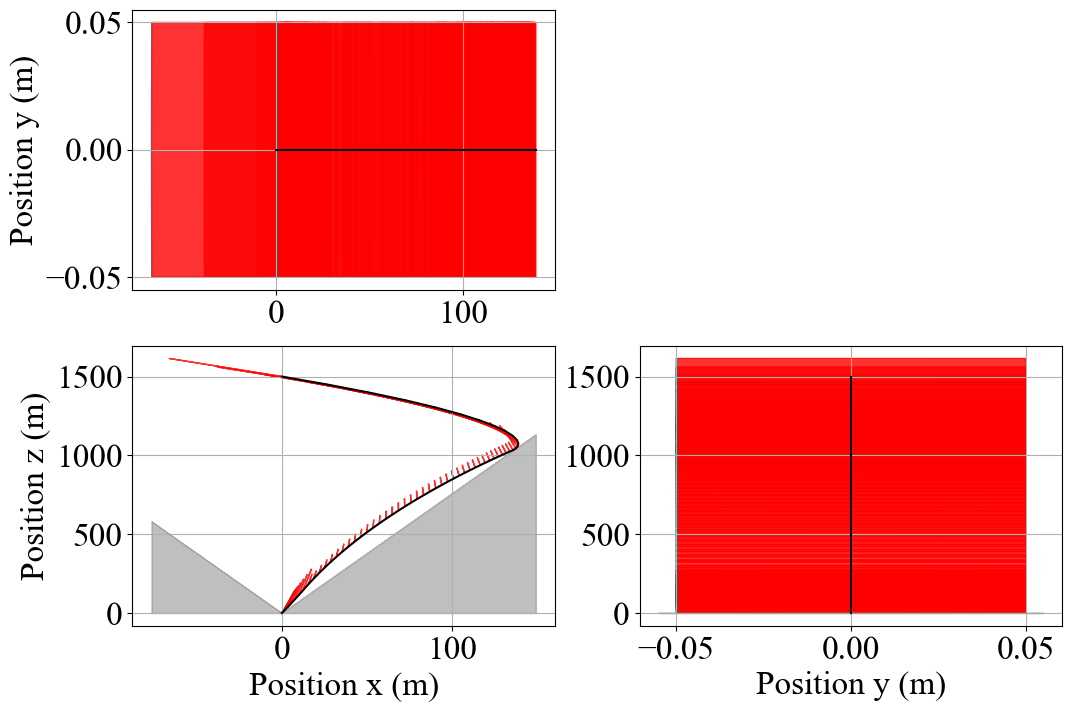

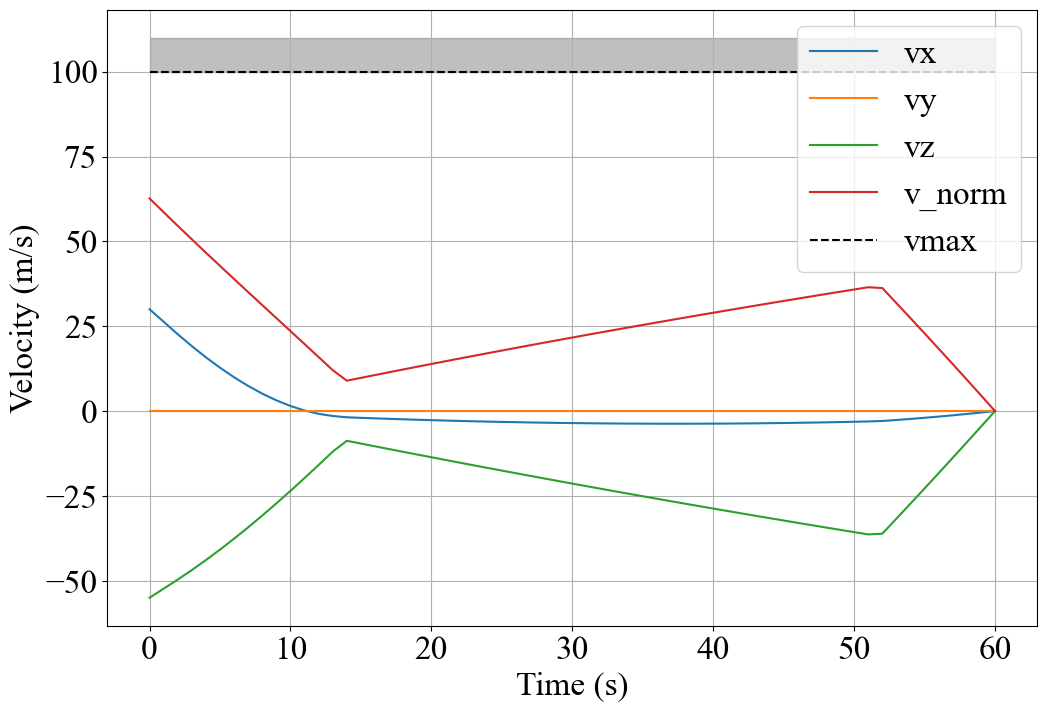

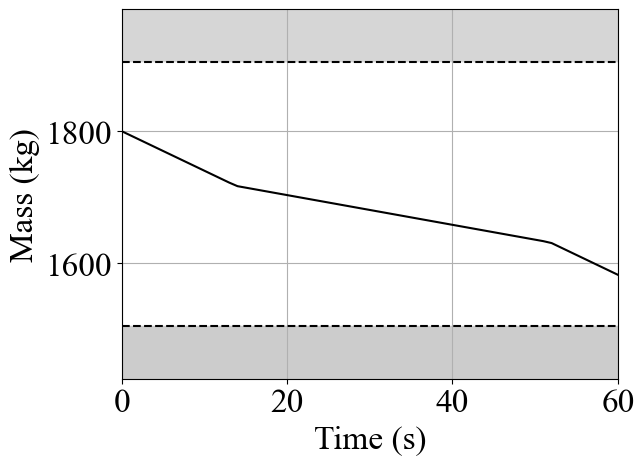

(60,)


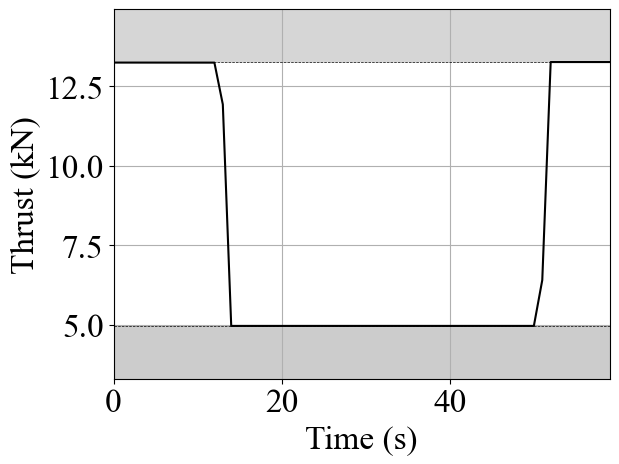

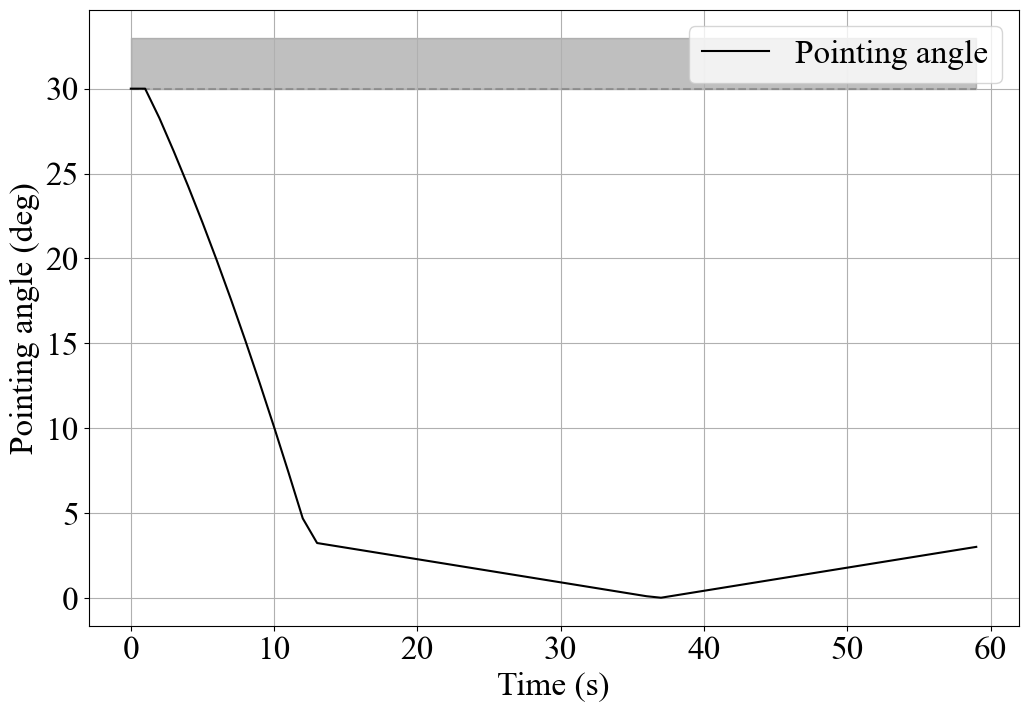

In [91]:
tf = 60.0
alt = 1500.0
mass = 1800.0
x0 = np.array([0, 0, alt, 30.0, 0, -55.0, mass])
dt = 1.0

# solve minimum fuel trajectory
N = int(tf / dt)
x0_log_mass = np.copy(x0)
x0_log_mass[6] = np.log(x0[6])
lcvx = lc.LCvxMinFuel(
    lander=lander,
    N=N,
    parameterize_x0=False,
    parameterize_tf=False,
    fixed_target=False,
    close_approach=True
)
prob = lcvx.problem(x0=x0_log_mass, tf=tf)
prob.solve(solver=cp.ECOS, verbose=False)

if prob.status != cp.OPTIMAL:
    print(f"Optimization failed: {prob.status}")

else:
    sol = lc.get_vars(prob, ["X", "U"])
    X_sol = sol["X"]
    U_sol = sol["U"]
    r, v, z, u, _ = lcvx.recover_variables(X_sol, U_sol)
    m = np.exp(z)
    X = np.hstack((r.T, v.T, m.reshape(-1, 1)))
    U = u.T * m[:-1].reshape(-1, 1)
    # --------------------

sol = lc.get_vars(prob, ["X", "U"])
X_sol = sol["X"]
U_sol = sol["U"]
r, v, z, u, sigma = lcvx.recover_variables(X_sol, U_sol)
m = np.exp(z)
X = np.hstack((r.T, v.T, m.reshape(-1, 1)))
U = u.T * m[:-1].reshape(-1, 1)
t = np.linspace(0, tf, lcvx.N + 1)

# Plot results
plot_3sides(t[:-1], X, U, uskip=1, gsa=lander.gsa)
plot_vel(t, X, lander.vmax)
plot_mass(t, X, lander.mdry, lander.mwet)
plot_thrust_mag(t[:-1], U, lander.rho2, lander.rho1)
plot_pointing(t[:-1], U, lander.pa)


In [93]:
def _solve(lcvx, prob, lander):
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except cp.SolverError:
        return None
    if prob.status != 'optimal':
        return None

    # Get solution
    sol = lc.get_vars(prob, ['X', 'U'])
    X_sol = sol['X']
    U_sol = sol['U']
    r, v, z, u, sigma = lcvx.recover_variables(X_sol, U_sol)
    valid, _ = lc.isolated_active_set_gs(r, lander.gsa)

    if not valid:
        return None
    return r, v, z, u, sigma

def get_reachset_params(x, tgo, nn_reach, lander_fov):
    from src.reachsteering import get_nn_reachset_param
    xmin, xmax, ymax, x_ymax, v_horiz_angle, _ = get_nn_reachset_param(x, tgo, nn_reach, lander_fov)
    return xmin, xmax, ymax, x_ymax, v_horiz_angle

def calculate_ellipse(xmin, x_ymax, xmax, ymax):
    a1 = x_ymax - xmin
    a2 = xmax - x_ymax
    b = ymax

    x_left = np.linspace(xmin, x_ymax, 100)
    y_left = b * np.sqrt(1 - ((x_left - x_ymax) ** 2) / ((a1 ** 2)))
    x_right = np.linspace(x_ymax, xmax, 100)
    y_right = b * np.sqrt(1 - ((x_right - x_ymax) ** 2) / ((a2 ** 2)))

    return x_left, y_left, x_right, y_right

def calculate_reachable_final_points(x, xmax, xmin, lcvx, prob, lander):
    theta_list = np.linspace(0, 180, 10) * np.pi / 180
    rf_list = []

    for theta in theta_list:
        c = np.array([np.cos(theta), np.sin(theta)])
        xc = np.array([(xmax + xmin) / 2, 0])
        c_xc_arr = np.array([
            [c[0] * xc[0], c[0] * xc[1]],
            [c[1] * xc[0], c[1] * xc[1]]
        ])
        lc.set_params(prob, {'alt': x[2],
                             'z_mass': np.log(x[6]),
                             'vx': x[3],
                             'vz': x[5],
                             'c': c,
                             'c_xc_arr': c_xc_arr})
        sol = _solve(lcvx, prob, lander)
        if sol is not None:
            rf_list.append(sol[0][:, -1])

    return rf_list

def plot_reachability_diagram(x_left, y_left, x_right, y_right, rf_list, fov_circle, maxrange=210, title=None, fname=None):
    plt.figure(figsize=(10, 10))
    plt.plot(x_left, y_left, 'k--', label='Reachable Surface by Neural Network')
    plt.plot(x_left, -y_left, 'k--')
    plt.plot(x_right, y_right, 'k--')
    plt.plot(x_right, -y_right, 'k--')
    
    for i, rf in enumerate(rf_list):
        if i == 0:
            plt.plot(rf[0], rf[1], 'kx', markersize=12, label='Reachable Surface via Convex Optimization')
        else:
            plt.plot(rf[0], rf[1], 'kx', markersize=12)

    plt.xlim(-maxrange, maxrange)
    plt.ylim(-maxrange, maxrange)
    plt.xlabel('x, m')
    plt.ylabel('y, m')
    plt.grid()
    # show legend at the bottom
    plt.legend(loc='lower center')
    plt.gca().set_aspect('equal', adjustable='box')
    if title is not None:
        plt.title(title)
    if fname is not None:
        plt.savefig(fname)
    plt.show()
    

def visualize_reachability(idx, X, t, tf, nn_reach, lander, N, fname=None):
    x = X[idx]
    tgo = tf - t[idx]

    title = f"Alt: {x[2]:.0f} m, Vx: {x[3]:.0f} m/s, Vz: {x[5]:.0f} m/s, TGO: {tgo:.0f} s"
    
    xmin, xmax, ymax, x_ymax, v_horiz_angle = get_reachset_params(x, tgo, nn_reach, lander.fov)
    x_left, y_left, x_right, y_right = calculate_ellipse(xmin, x_ymax, xmax, ymax)
    
    lcvx = lc.LCvxReachabilityRxy(lander=lander, N=N, directional_cstr=True)
    prob = lcvx.problem(tf=tf)
    rf_list = calculate_reachable_final_points(x, xmax, xmin, lcvx, prob, lander)

    fov_circle = np.array([np.cos(np.linspace(0, 2 * np.pi, 100)), np.sin(np.linspace(0, 2 * np.pi, 100))]) * x[2] * np.tan(lander.fov / 2)
    
    plot_reachability_diagram(x_left, y_left, x_right, y_right, rf_list, fov_circle, title=title, fname=fname)


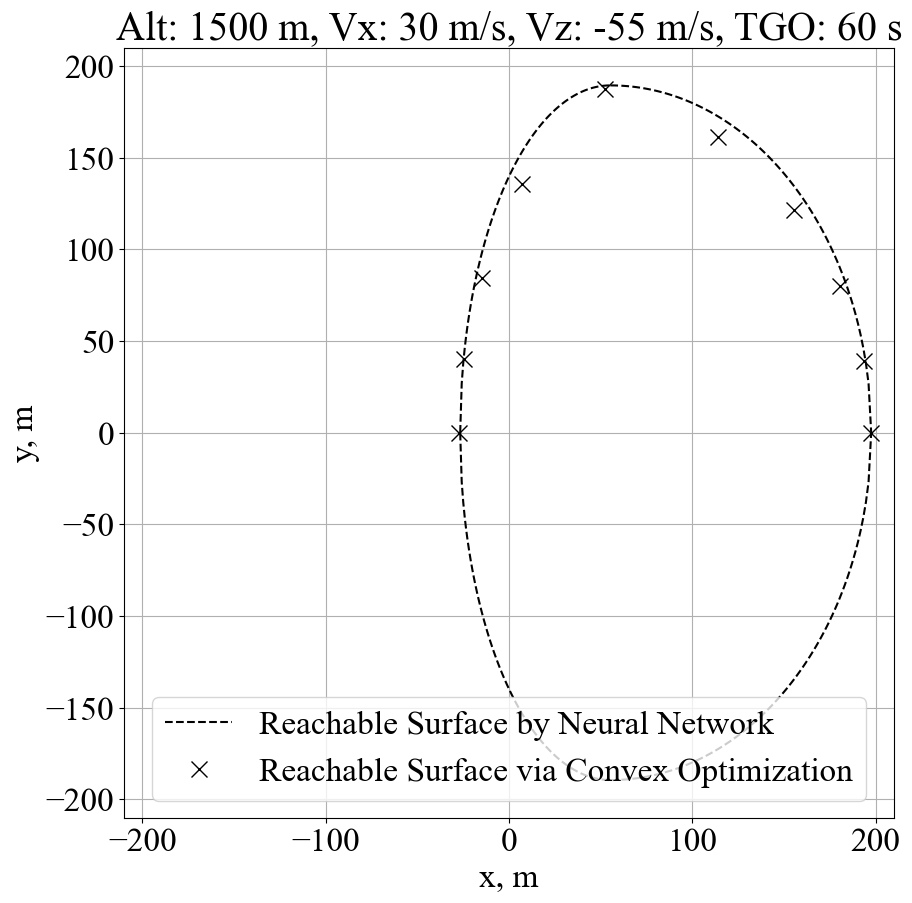

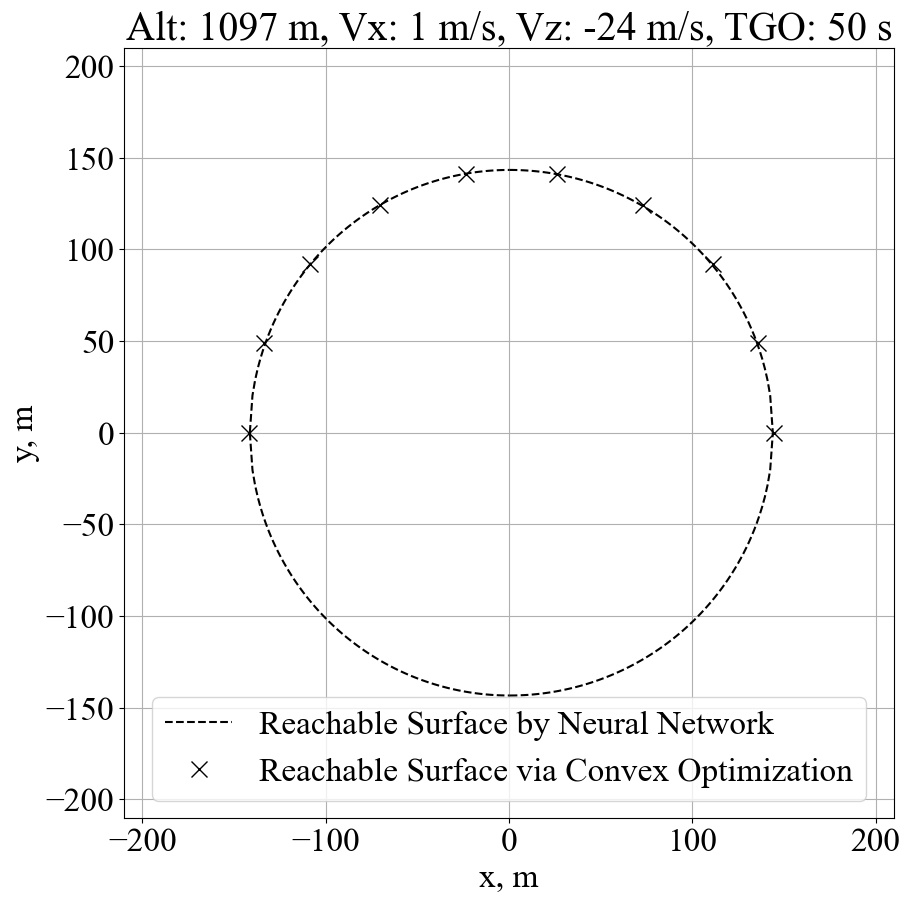

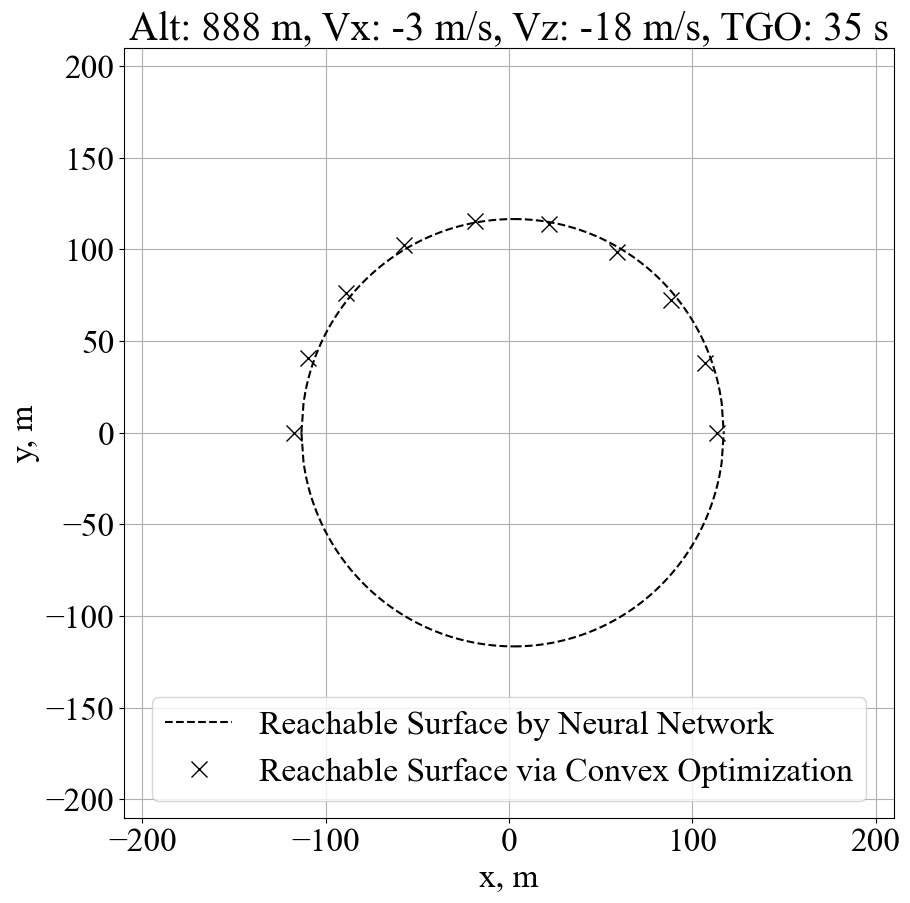

In [97]:
# make font larger
plt.rcParams.update({'font.size': 24})

visualize_reachability(0, X, t, tf, nn_reach, lander, N, fname='reachability_0.png')
visualize_reachability(10, X, t, tf, nn_reach, lander, N, fname='reachability_10.png')
visualize_reachability(25, X, t, tf, nn_reach, lander, N, fname='reachability_20.png')

In [70]:
base_dir = "../saved/controllable_set/reachset_train/20231115-025054"
data_random = np.load(os.path.join(base_dir, "data_random.npy"))
data_structured = np.load(os.path.join(base_dir, "data_structured.npy"))
reachset = np.vstack((data_structured, data_random))

print(f"Random data shape: {data_random.shape}")
print(f"Structured data shape: {data_structured.shape}")
print(f"Reachset shape: {reachset.shape}")

Random data shape: (68140, 11)
Structured data shape: (20585, 11)
Reachset shape: (88725, 11)


In [71]:
hidden_layers = [256, 256, 256]
model = lrn.NeuralReach(hidden_layers=hidden_layers)
model.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20231130-175526/mlp_reach/mlp_reach.pt'))
model.eval()

NeuralReach(
  (layers): ModuleList(
    (0): Linear(in_features=5, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=256, out_features=4, bias=True)
    (10): Sigmoid()
  )
)

In [72]:
import torch
import datetime
from torch.utils.data import DataLoader, random_split

# define hyperparameters
train_data_rate = 0.95
batch_size = 1024

# create dataset and dataloader
dataset = lrn.ReachsetDataset(reachset=reachset)
n_data = len(dataset)
train_size = int(train_data_rate * n_data)
test_size = n_data - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

In [73]:
model.eval()
test_loader = DataLoader(test_set, batch_size=1, shuffle=True)
n_max = 10000
n_test = min(n_max, len(test_loader))
x_mat = np.zeros((n_test, 5))
y_mat = np.zeros((n_test, 4))
y_hat_mat = np.zeros((n_test, 4))
error_mat = np.zeros((n_test, 4))
with torch.no_grad():
    for i, (_, x, y) in enumerate(tqdm(test_loader)):
        if i >= n_test:
            break

        # forward
        y_hat = model(x)

        # scale back
        alt, vx, vz, z, tgo = lrn.inverse_transform_ic(alt_=x[0, 0], vx_=x[0, 1], vz_=x[0, 2], z_=x[0, 3], tgo_=x[0, 4])
        y_hat = lrn.inverse_transform_reachsetparam(xmin_=y_hat[0, 0], xmax_=y_hat[0, 1], ymax_=y_hat[0, 2], x_ymax_=y_hat[0, 3], alt=alt)
        y = lrn.inverse_transform_reachsetparam(xmin_=y[0, 0], xmax_=y[0, 1], ymax_=y[0, 2], x_ymax_=y[0, 3], alt=alt)

        # save 
        x_mat[i, :] = [alt, vx, vz, z, tgo]
        y_mat[i, :] = np.array(y)
        y_hat_mat[i, :] = np.array(y_hat)
        error_mat[i, :] = np.array(y_hat) - np.array(y)

100%|██████████| 4437/4437 [00:03<00:00, 1340.92it/s]


xmin: mean error = 1.437, std error = 3.944
xmax: mean error = 0.296, std error = 0.626
ymax: mean error = 0.859, std error = 2.108
x_ymax: mean error = 1.197, std error = 2.197
xmin: mean error = 7.145 %, std error = 38.457 %
xmax: mean error = 1.283 %, std error = 12.340 %
ymax: mean error = 1.589 %, std error = 7.733 %
x_ymax: mean error = 5.873 %, std error = 37.273 %


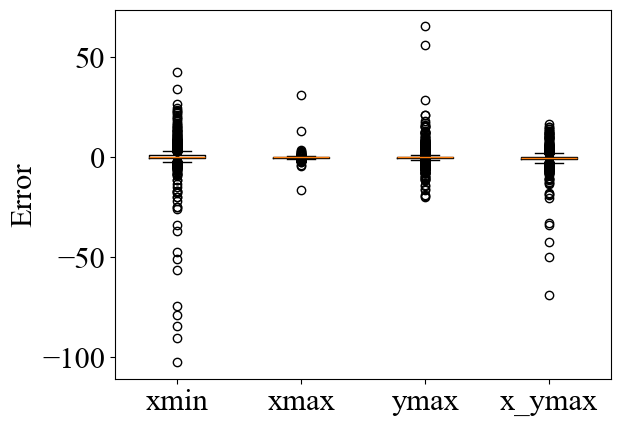

In [79]:
# print mean and std of error for each column
param_names = ["xmin", "xmax", "ymax", "x_ymax"]
for i, param_name in enumerate(param_names):
    mean_error = np.mean(np.abs(error_mat[:, i]))
    std_error = np.std(np.abs(error_mat[:, i]))
    print(f"{param_name}: mean error = {mean_error:.3f}, std error = {std_error:.3f}")

# print mean and std of error for each column
# but this time calc error as relative error
param_names = ["xmin", "xmax", "ymax", "x_ymax"]
x_scale = np.abs((y_mat[:, 0] - y_mat[:, 1]) / 2)
y_scale = np.abs(y_mat[:, 2])
scales = [x_scale, x_scale, y_scale, x_scale]
for i, param_name in enumerate(param_names):
    mean_error = np.mean(np.abs(error_mat[:, i] / scales[i])) * 100
    std_error = np.std(np.abs(error_mat[:, i] / scales[i])) * 100
    print(f"{param_name}: mean error = {mean_error:.3f} %, std error = {std_error:.3f} %")

# plot error; make boxplot for each column
fig, ax = plt.subplots()
ax.boxplot(error_mat)
ax.set_xticklabels(["xmin", "xmax", "ymax", "x_ymax"])
ax.set_ylabel("Error")
plt.show()